# **Technical Note: Feature Selection**

##### 1. Filter Method: Correlation Threshold

In [1]:
import pandas as pd
import numpy as np

toothpaste = pd.read_csv("toothpaste_intent.csv")
toothpaste.head(10)

,Participant,X1,X2,X3,X4,X5,X6,purchase_intent
0,1,7,3,6,4,2,4,36.969209
1,2,1,3,2,4,5,4,68.865419
2,3,6,2,7,4,1,3,30.806181
3,4,4,5,4,6,2,5,45.585134
4,5,1,2,2,3,6,2,80.794320
5,6,6,3,6,4,2,4,32.847697
6,7,5,3,6,3,4,3,52.704074
7,8,6,4,7,4,1,4,25.944001
8,9,3,4,2,3,6,3,79.764049
9,10,2,6,2,6,7,6,69.484635


In [2]:
M = toothpaste.iloc[:, 1:7].corr()
M

,X1,X2,X3,X4,X5,X6
X1,1.000000,-0.053218,0.873090,-0.086162,-0.857637,0.004168
X2,-0.053218,1.000000,-0.155020,0.572212,0.019746,0.640465
X3,0.873090,-0.155020,1.000000,-0.247788,-0.777848,-0.018069
X4,-0.086162,0.572212,-0.247788,1.000000,-0.006582,0.640465
X5,-0.857637,0.019746,-0.777848,-0.006582,1.000000,-0.136403
X6,0.004168,0.640465,-0.018069,0.640465,-0.136403,1.000000


In [3]:
# Identify column indices of features to remove (correlation > 0.8)
from feature_engine.selection import DropCorrelatedFeatures

# Show variables to be removed
drop_corr = DropCorrelatedFeatures(threshold=0.8)
df_reduced = drop_corr.fit_transform(toothpaste.iloc[:, 1:7])

drop_corr.features_to_drop_

['X3', 'X5']

In [4]:
# Create a new dataset excluding X3 and X5
toothpaste_reduced = toothpaste.drop(columns=drop_corr.features_to_drop_)
toothpaste_reduced.head(10)

,Participant,X1,X2,X4,X6,purchase_intent
0,1,7,3,4,4,36.969209
1,2,1,3,4,4,68.865419
2,3,6,2,4,3,30.806181
3,4,4,5,6,5,45.585134
4,5,1,2,3,2,80.794320
5,6,6,3,4,4,32.847697
6,7,5,3,3,3,52.704074
7,8,6,4,4,4,25.944001
8,9,3,4,3,3,79.764049
9,10,2,6,6,6,69.484635


In [5]:
import statsmodels.api as sm

X = sm.add_constant(toothpaste[['X1','X2','X3','X4','X5','X6']])
Y = toothpaste['purchase_intent']

model_original = sm.OLS(Y, X).fit()
model_original.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:        purchase_intent   R-squared:                       0.914
Model:                            OLS   Adj. R-squared:                  0.892
Method:                 Least Squares   F-statistic:                     40.74
Date:                Sat, 17 Jan 2026   Prob (F-statistic):           3.99e-11
Time:                        13:21:57   Log-Likelihood:                -94.010
No. Observations:                  30   AIC:                             202.0
Df Residuals:                      23   BIC:                             211.8
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         69.5727     10.916      6.373      0.000      46.991      92.155
X1            -0.5469      1.586     -0.345      0.733      -3.827       2.733
X2            -1.0914      1.189     -0.918      0.368      -3.552       1.369
X3            -5.2445      1.327     -3.953      0.001      -7.989      -2.500
X4            -2.4179      1.269     -1.906      0.069      -5.042       0.206
X5             4.2176      1.268      3.326      0.003       1.594       6.841
X6             0.9197      1.318      0.698      0.492      -1.807       3.646
==============================================================================
Omnibus:                        1.529   Durbin-Watson:                   1.550
Prob(Omnibus):                  0.466   Jarque-Bera (JB):                1.173
Skew:                          -0.476   Prob(JB):                        0.556
Kurtosis:                       2.818   Cond. No.                         93.9
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [6]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

vif_values = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
pd.DataFrame([vif_values], columns=X.columns, index=['VIF'])

,const,X1,X2,X3,X4,X5,X6
VIF,88.812537,7.111221,1.922292,5.364111,2.186942,4.214757,2.424


##### 2. Wrapper Method: Stepwise Selection

In [ ]:
Boston = sm.datasets.get_rdataset("Boston","MASS").data
Boston.head(10)

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,black,lstat,medv
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,5.33,36.2
5,0.02985,0.0,2.18,0,0.458,6.430,58.7,6.0622,3,222,18.7,394.12,5.21,28.7
6,0.08829,12.5,7.87,0,0.524,6.012,66.6,5.5605,5,311,15.2,395.60,12.43,22.9
7,0.14455,12.5,7.87,0,0.524,6.172,96.1,5.9505,5,311,15.2,396.90,19.15,27.1
8,0.21124,12.5,7.87,0,0.524,5.631,100.0,6.0821,5,311,15.2,386.63,29.93,16.5
9,0.17004,12.5,7.87,0,0.524,6.004,85.9,6.5921,5,311,15.2,386.71,17.10,18.9


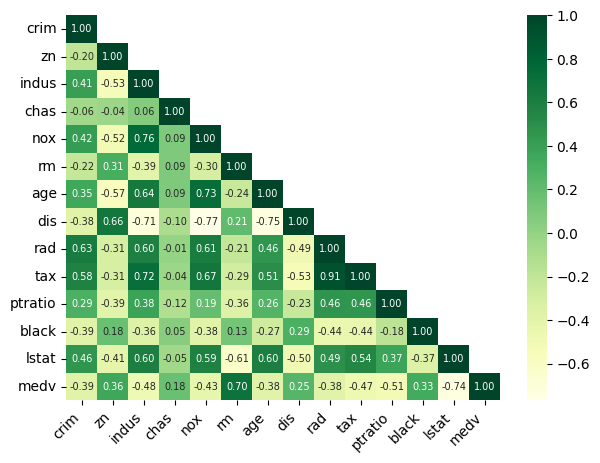

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

M = Boston.corr()
mask = np.triu(np.ones_like(M, dtype='bool'), k=1)

plt.figure(figsize=(7,5))
sns.heatmap(M,  # Correlation matriz
            mask=mask,  # Visualize the under part of the graphic
            annot=True,     # Include the numbers inside the squares
            fmt=".2f",      # 2 Decimals 
            cmap="YlGn",    # Assing green-yellow color
            annot_kws={'size':7})   # Determine the size of the numbers inside the squares
plt.xticks(rotation=45,ha='right')
plt.show()

In [39]:
# Fit a null (intercept-only) model
X1 = np.ones((len(Boston),1))
Y1 = Boston['medv']

null_model = sm.OLS(Y1, X1).fit()
null_model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                   medv   R-squared:                       0.000
Model:                            OLS   Adj. R-squared:                  0.000
Method:                 Least Squares   F-statistic:                       nan
Date:                Sat, 17 Jan 2026   Prob (F-statistic):                nan
Time:                        16:29:14   Log-Likelihood:                -1840.2
No. Observations:                 506   AIC:                             3682.
Df Residuals:                     505   BIC:                             3687.
Df Model:                           0                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         22.5328      0.409     55.111      0.000      21.730      23.336
==============================================================================
Omnibus:                       90.975   Durbin-Watson:                   0.528
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              148.412
Skew:                           1.105   Prob(JB):                     5.93e-33
Kurtosis:                       4.469   Cond. No.                         1.00
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [40]:
# Fit the full model
X2 = sm.add_constant(Boston.drop(columns=["medv"]))
Y2 = Boston['medv']

full_model = sm.OLS(Y2, X2).fit()
full_model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                   medv   R-squared:                       0.741
Model:                            OLS   Adj. R-squared:                  0.734
Method:                 Least Squares   F-statistic:                     108.1
Date:                Sat, 17 Jan 2026   Prob (F-statistic):          6.72e-135
Time:                        16:34:37   Log-Likelihood:                -1498.8
No. Observations:                 506   AIC:                             3026.
Df Residuals:                     492   BIC:                             3085.
Df Model:                          13                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         36.4595      5.103      7.144      0.000      26.432      46.487
crim          -0.1080      0.033     -3.287      0.001      -0.173      -0.043
zn             0.0464      0.014      3.382      0.001       0.019       0.073
indus          0.0206      0.061      0.334      0.738      -0.100       0.141
chas           2.6867      0.862      3.118      0.002       0.994       4.380
nox          -17.7666      3.820     -4.651      0.000     -25.272     -10.262
rm             3.8099      0.418      9.116      0.000       2.989       4.631
age            0.0007      0.013      0.052      0.958      -0.025       0.027
dis           -1.4756      0.199     -7.398      0.000      -1.867      -1.084
rad            0.3060      0.066      4.613      0.000       0.176       0.436
tax           -0.0123      0.004     -3.280      0.001      -0.020      -0.005
ptratio       -0.9527      0.131     -7.283      0.000      -1.210      -0.696
black          0.0093      0.003      3.467      0.001       0.004       0.015
lstat         -0.5248      0.051    -10.347      0.000      -0.624      -0.425
==============================================================================
Omnibus:                      178.041   Durbin-Watson:                   1.078
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              783.126
Skew:                           1.521   Prob(JB):                    8.84e-171
Kurtosis:                       8.281   Cond. No.                     1.51e+04
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 1.51e+04. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

In [42]:
vif_values_full = [variance_inflation_factor(X2.values, i) for i in range(X2.shape[1])]
pd.DataFrame([vif_values_full], columns=X2.columns, index=['VIF'])

,const,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,black,lstat
VIF,585.265238,1.792192,2.298758,3.991596,1.073995,4.39372,1.933744,3.100826,3.955945,7.484496,9.008554,1.799084,1.348521,2.941491


In [43]:
# Selected model: Step() function does not exist in Python
Xs = sm.add_constant(Boston[['lstat','rm','ptratio','dis','nox','chas','black','zn','crim','rad','tax']])
Ys = Boston['medv']

step_model = sm.OLS(Ys, Xs).fit()
step_model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                   medv   R-squared:                       0.741
Model:                            OLS   Adj. R-squared:                  0.735
Method:                 Least Squares   F-statistic:                     128.2
Date:                Sat, 17 Jan 2026   Prob (F-statistic):          5.54e-137
Time:                        17:14:12   Log-Likelihood:                -1498.9
No. Observations:                 506   AIC:                             3022.
Df Residuals:                     494   BIC:                             3072.
Df Model:                          11                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         36.3411      5.067      7.171      0.000      26.385      46.298
lstat         -0.5226      0.047    -11.019      0.000      -0.616      -0.429
rm             3.8016      0.406      9.356      0.000       3.003       4.600
ptratio       -0.9465      0.129     -7.334      0.000      -1.200      -0.693
dis           -1.4927      0.186     -8.037      0.000      -1.858      -1.128
nox          -17.3760      3.535     -4.915      0.000     -24.322     -10.430
chas           2.7187      0.854      3.183      0.002       1.040       4.397
black          0.0093      0.003      3.475      0.001       0.004       0.015
zn             0.0458      0.014      3.390      0.001       0.019       0.072
crim          -0.1084      0.033     -3.307      0.001      -0.173      -0.044
rad            0.2996      0.063      4.726      0.000       0.175       0.424
tax           -0.0118      0.003     -3.493      0.001      -0.018      -0.005
==============================================================================
Omnibus:                      178.430   Durbin-Watson:                   1.078
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              787.785
Skew:                           1.523   Prob(JB):                    8.60e-172
Kurtosis:                       8.300   Cond. No.                     1.47e+04
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 1.47e+04. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

In [45]:
# Compare AIC
print(f"AIC of the full model: ",full_model.aic)
print(f"AIC of the step model: ",step_model.aic)

AIC of the full model:  3025.608594075548
AIC of the step model:  3021.726387825062


In [ ]:
# Check wich variables were removed
step_model.params

const      36.341145
lstat      -0.522553
rm          3.801579
ptratio    -0.946525
dis        -1.492711
nox       -17.376023
chas        2.718716
black       0.009291
zn          0.045845
crim       -0.108413
rad         0.299608
tax        -0.011778
dtype: float64

In [47]:
vif_step_values = [variance_inflation_factor(Xs.values, i) for i in range(Xs.shape[1])]
pd.DataFrame([vif_step_values], columns=Xs.columns, index=["VIF"])

,const,lstat,rm,ptratio,dis,nox,chas,black,zn,crim,rad,tax
VIF,579.255845,2.581984,1.834806,1.757681,3.44342,3.778011,1.059819,1.341559,2.239229,1.789704,6.861126,7.272386
